# Imports der Bibliotheken

In [2]:
#Masterprojekt SFH - 1 Verbraucher, 1 Wärmepumpe, 1 Speicher
import logging
logger = logging.getLogger("gurobipy")
logger.propagate = False

import sys
import pandas as pd
import pypsaheat as ph
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Einlesen Lastgänge & Zuordnung der Daten

In [3]:
#Einlesen der Lastgänge
input_data = pd.read_csv('Inputs/MasterProjekt_Lastprofile.csv', index_col=0)
input_data

#limitieren der Daten auf 3 Wochen
start = 0      # 0 = Anfang des Jahres
input_data = input_data.iloc[start : start + 504]
input_data.index = range(len(input_data)) 

In [4]:
input_data = input_data.drop(columns=["Waerme gesamt (kW)"]).rename(
    columns={"Temp C": "temp","Zone 2-Trinkwarmwasser (kW)": "heat_water","Zone 2-Raumwaerme (kW)": "heat_space",}
)

input_data = input_data[["temp", "heat_water", "heat_space"]]
input_data.index.name = "index"
input_data
input_data.to_csv("Inputs/load_profile_3_weeks.csv", index=True)

In [5]:
input_data

,temp,heat_water,heat_space
index,,,
0,6.286,0.2,1.7
1,5.997,0.1,1.7
2,5.705,0.1,1.8
3,5.534,0.0,1.7
4,5.451,0.1,1.8
...,...,...,...
499,-4.842,0.8,5.8
500,-5.690,0.7,5.8
501,-6.235,0.6,5.6


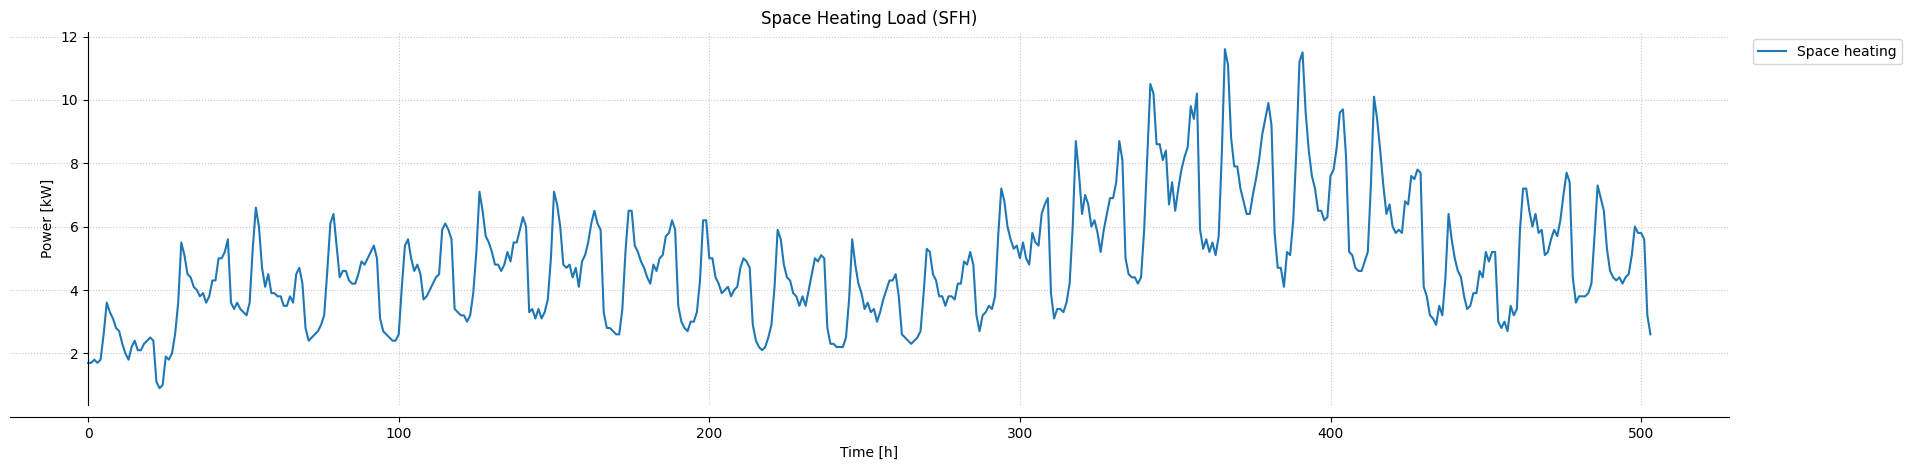

In [6]:
#Zuordnung der Daten aus den Lastgängen
raumwaerme = input_data['heat_space'] #Heizlast von SFH in kW
ax = raumwaerme.plot(figsize=(19.2, 4.8), label='Space heating')

ax.set_title('Space Heating Load (SFH)')
ax.set_xlabel('Time [h]')
ax.set_ylabel('Power [kW]')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

# Make axes intersect at (0,0)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.grid(linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

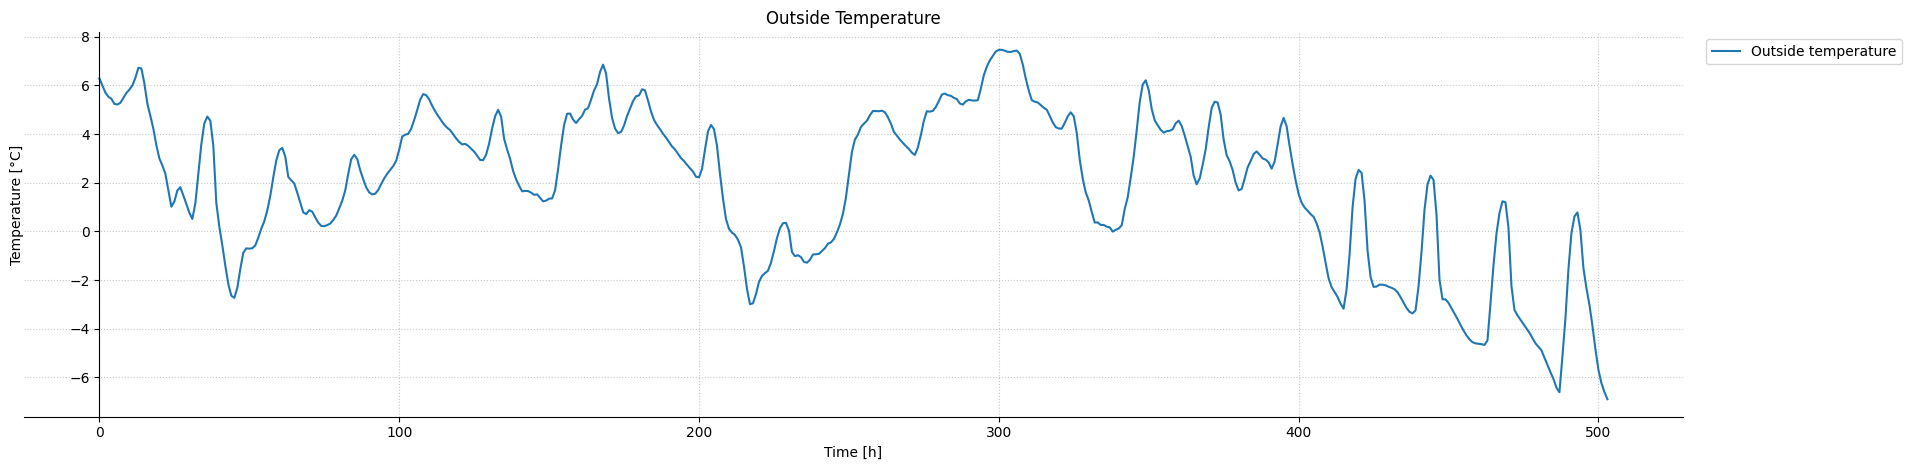

In [7]:
# aussentemperatur = df_data_weather['DE_temperature']
aussentemperatur = input_data['temp']
ax = aussentemperatur.plot(figsize=(19.2, 4.8), label='Outside temperature')

ax.set_title('Outside Temperature')
ax.set_xlabel('Time [h]')
ax.set_ylabel('Temperature [°C]')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

# y-Achse bei x=0, x-Achse bleibt unten am Rand
ax.spines['left'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.yaxis.set_label_coords(0, 0.55)

ax.grid(linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# System Eigenschaften

In [8]:
#Wärmespeicher Eigenschaften 
Store_height = 2 #m
Store_base = 0.8 #m²
Store_layer = 3

T_Warmwasser = 55

#Wärmepumpen Leistung
HP_power = 20 #kW Wärmepumpenleistung

#Strom
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug
grid_power = np.inf #kW Hausanschluss Leistung

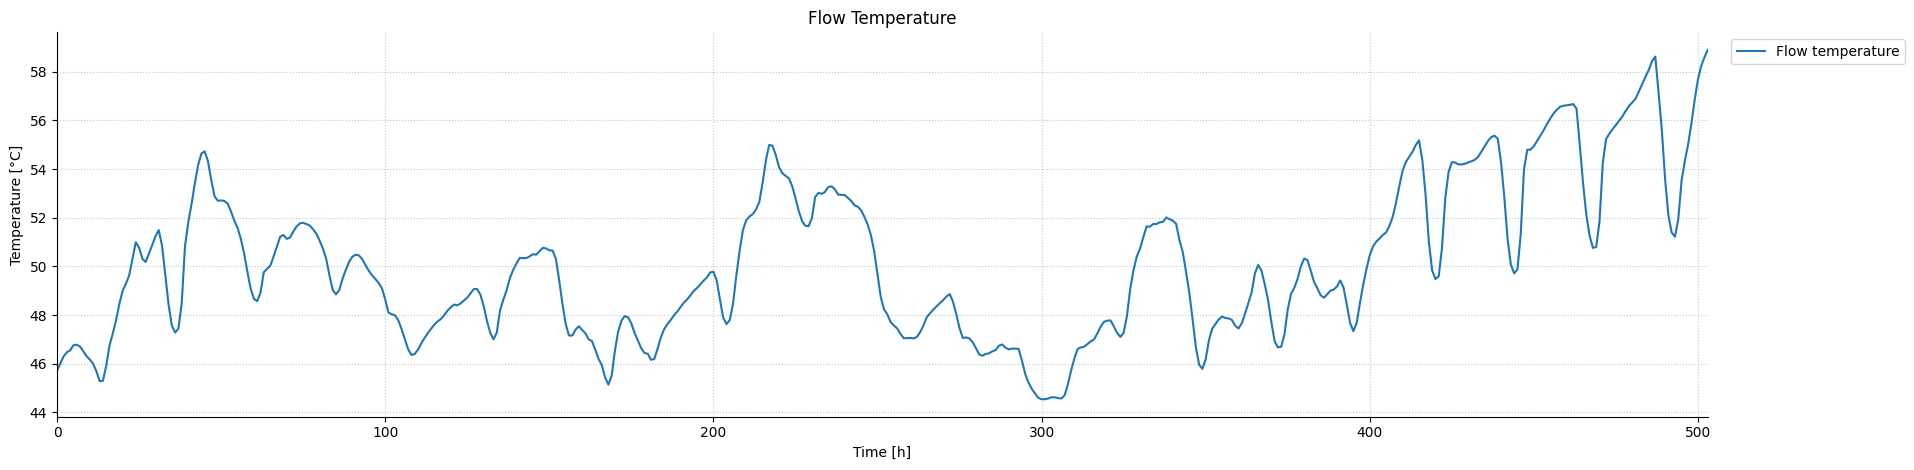

In [9]:
# Vorlauftemperatur für Heizsystem
T_at_0 = 52  # °C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  # °C/°C Steigung der Heizkurve
T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur)
ax = T_flow.plot(figsize=(19.2, 4.8), label='Flow temperature')

ax.set_title('Flow Temperature')
ax.set_xlabel('Time [h]')
ax.set_ylabel('Temperature [°C]')
ax.yaxis.set_label_coords(-0.02, 0.55)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

# Nur oben/rechts ausblenden, Achsen am Rand belassen (kein Schnittpunkt bei 0)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.set_xlim(0, T_flow.index.max())

ax.grid(linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Modellerstellung

In [10]:
# Aufbau des Modells
n = ph.HeatNetwork()

n.set_snapshots(input_data.index)

n.add("Bus",  
      name = "electricity"      
)

n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
  )

n.add('Load', 
      bus = 'electricity', 
      name = 'Elektrische Last',
      #p_set = power_demand_hp
)

# Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = raumwaerme,
      T_demand = T_flow
      )

# Hinzufügen eines Schichtspeichers mit konstanten Volumschichten
n.add('HeatStore',
      name='hs',
      constant='volume',
      height=Store_height,
      base=Store_base,
      N_layer=Store_layer,       
      cyclic=False,
      U_wall=0.15,                 
      T_initial=[55, 50, 45]     # numerische Liste (Länge = N_layer) oder single float
)

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp1',
      bus0 = 'electricity',
      p_nom = HP_power,          # Nennleistung (thermal kW)
      m_nom = 700, # kg/h 
      heat_store = 'hs',
      T_source = aussentemperatur,
      T_nom = 65,
      heat_source  = 'air'
      )

#Hinzufügen der Warmwasserlast
# n.add('HeatLoad',
#       name = 'heat_water_demand',
#       heat_store = 'hs',
#       p_set = input_data['DE_heat_profile_water_SFH']/1000,
#       T_demand = T_Warmwasser
#       )

In [11]:
n.heat_loads

attribute,heat_store,carrier,type,p_set,T_demand,T_diff_return,internal_exchange,outlet_height,inlet_height
HeatLoad,,,,,,,,,
heat_space_demand,hs,,,0.0,50.0,10.0,False,1.0,0.0


# Optimierung

In [12]:
# Optimierung mit rollierendem Horizont
n.optimize.optimize_with_rolling_horizon(horizon = 24, overlap = 12)

INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [0:23] (1/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2733977
Academic license - for non-commercial use only - expires 2026-11-06


INFO:linopy.io: Writing time: 0.05s


Read LP format model from file C:\Users\Christian\AppData\Local\Temp\linopy-problem-4dpzfih5.lp
Reading time = 0.01 seconds
obj: 672 rows, 216 columns, 1557 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5700X3D 8-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 672 rows, 216 columns and 1557 nonzeros
Model fingerprint: 0x45e75624
Variable types: 192 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [7e-04, 1e+02]
  Objective range  [3e-01, 3e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e-03, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 312 rows and 48 columns
Presolve time: 0.01s
Presolved: 360 rows, 168 columns, 1125 nonzeros
Variable types: 144 continuous, 24 integer (24 binary)

Root rel

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 216 primals, 0 duals
Objective: 9.06e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [12:35] (2/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


...

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 216 primals, 0 duals
Objective: 2.51e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [492:503] (42/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2733977
Academic license - for non-commercial use only - expires 2026-11-06


INFO:linopy.io: Writing time: 0.04s


Read LP format model from file C:\Users\Christian\AppData\Local\Temp\linopy-problem-b_wxfxm7.lp
Reading time = 0.01 seconds
obj: 336 rows, 108 columns, 777 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5700X3D 8-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 336 rows, 108 columns and 777 nonzeros
Model fingerprint: 0xccbc2b2a
Variable types: 96 continuous, 12 integer (12 binary)
Coefficient statistics:
  Matrix range     [7e-04, 1e+02]
  Objective range  [3e-01, 3e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e-03, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 156 rows and 24 columns
Presolve time: 0.00s
Presolved: 180 rows, 84 columns, 561 nonzeros
Variable types: 72 continuous, 12 integer (12 binary)

Root relaxatio

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 108 primals, 0 duals
Objective: 1.35e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.


In [13]:
#Zuordnung der Ergebnisse
m = n.optimize.create_model()

Index(['electricity'], dtype='object', name='Bus')


In [14]:
#Inhalte der Optimierung
m

Linopy MILP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * HeatStore-hs-T_layer (snapshot, layer)
 * HeatPump-status (snapshot, HeatPump)
 * HeatPump-hp1-T_supply (snapshot, HeatPump)
 * HeatPump-hp1-T_bin_layer_hs (snapshot, layer)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * HeatStore-hs-layer_balance (snapshot, layer)
 * HeatStore-hs-max_layer_temp (snapshot, layer)
 * HeatStore-hs-only_one_hp_active (snapshot)
 * HeatPump-hp1-max_T_bin_layer_hs (HeatPump, snapshot, layer)
 * HeatPump-hp1-min_T_bin_layer_hs (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_bin_layer_eq_T_layer_hs_max (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_bin_layer_eq_T_layer_hs_min (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_supply_status (snapshot, HeatPump)
 * HeatPump-hp1-p_heat_lower (layer, snapshot, HeatPump)
 * HeatPump-hp1-p_heat_upper (layer, snapshot, HeatP

In [15]:
n.heat_pumps_t

{'T_source':             hp1
 snapshot       
 0         6.286
 1         5.997
 2         5.705
 3         5.534
 4         5.451
 ...         ...
 499      -4.842
 500      -5.690
 501      -6.235
 502      -6.605
 503      -6.903
 
 [504 rows x 1 columns],
 'T_nom': HeatPump   hp1
 snapshot      
 0         65.0
 1         65.0
 2         65.0
 3         65.0
 4         65.0
 ...        ...
 499       65.0
 500       65.0
 501       65.0
 502       65.0
 503       65.0
 
 [504 rows x 1 columns],
 'p_min_pu': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'p_max_pu': Empty Data

In [16]:
heatstore_daten=n.heat_stores_t.T

# Python Ergebnisse

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

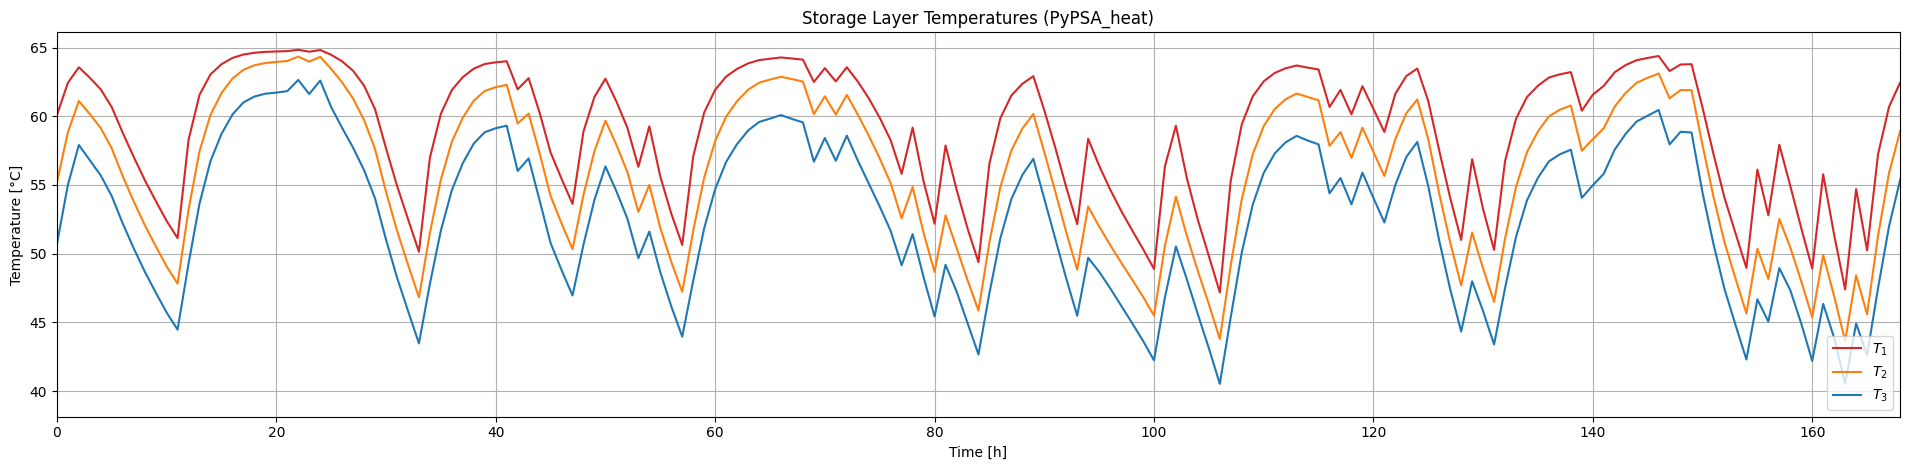

In [76]:
#Storage Layer Temperatures 1 Woche
n.heat_stores_t.T.plot(figsize=(19.2, 4.8), color=['tab:red', 'tab:orange', 'tab:blue'])

plt.title('Storage Layer Temperatures (PyPSA_heat)')
plt.xlabel('Time [h]')
plt.ylabel('Temperature [°C]')
plt.xlim(0, 168)
plt.legend(labels=['$T_1$', '$T_2$', '$T_3$'], loc='lower right', bbox_to_anchor=(1, 0))
plt.grid()
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/py_speicherschichten - 1 Wochen.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

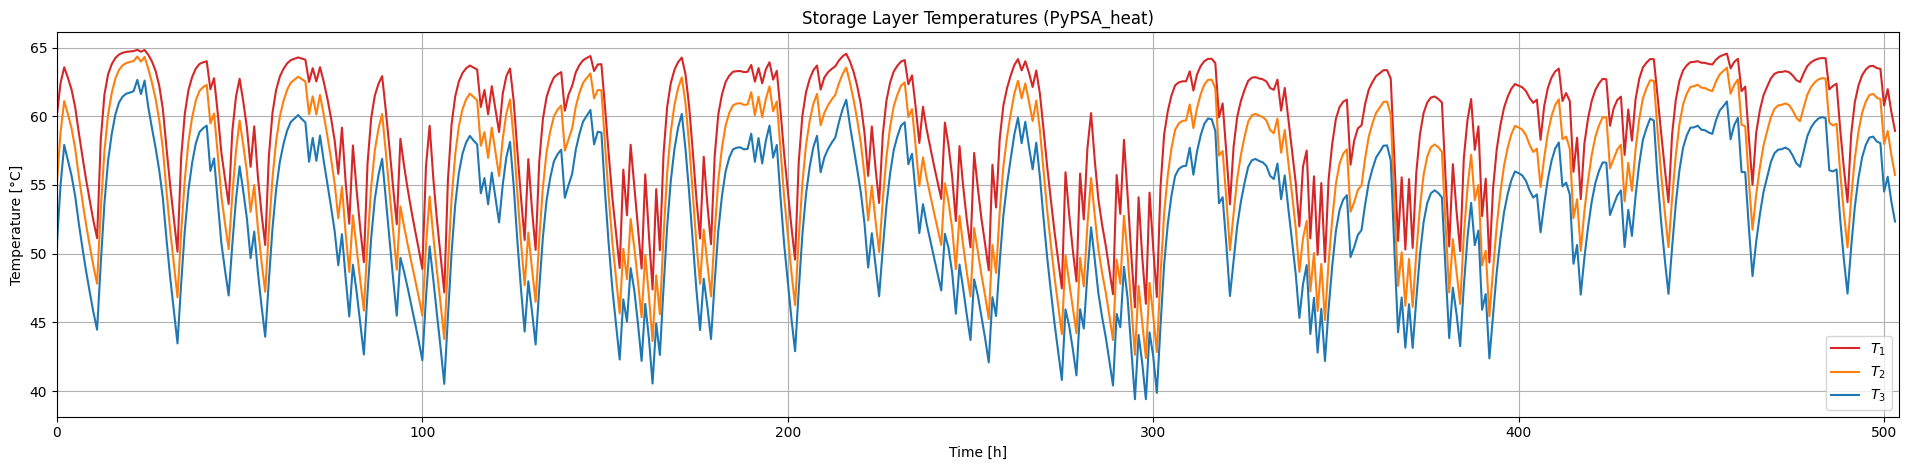

In [77]:
#Storage Layer Temperatures 3 Wochen
n.heat_stores_t.T.plot(figsize=(19.2, 4.8), color=['tab:red', 'tab:orange', 'tab:blue'])

plt.title('Storage Layer Temperatures (PyPSA_heat)')
plt.xlabel('Time [h]')
plt.ylabel('Temperature [°C]')
plt.xlim(0, 504)
plt.legend(labels=['$T_1$', '$T_2$', '$T_3$'], loc='lower right', bbox_to_anchor=(1, 0))
plt.grid()
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/py_speicherschichten - 3 Wochen.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

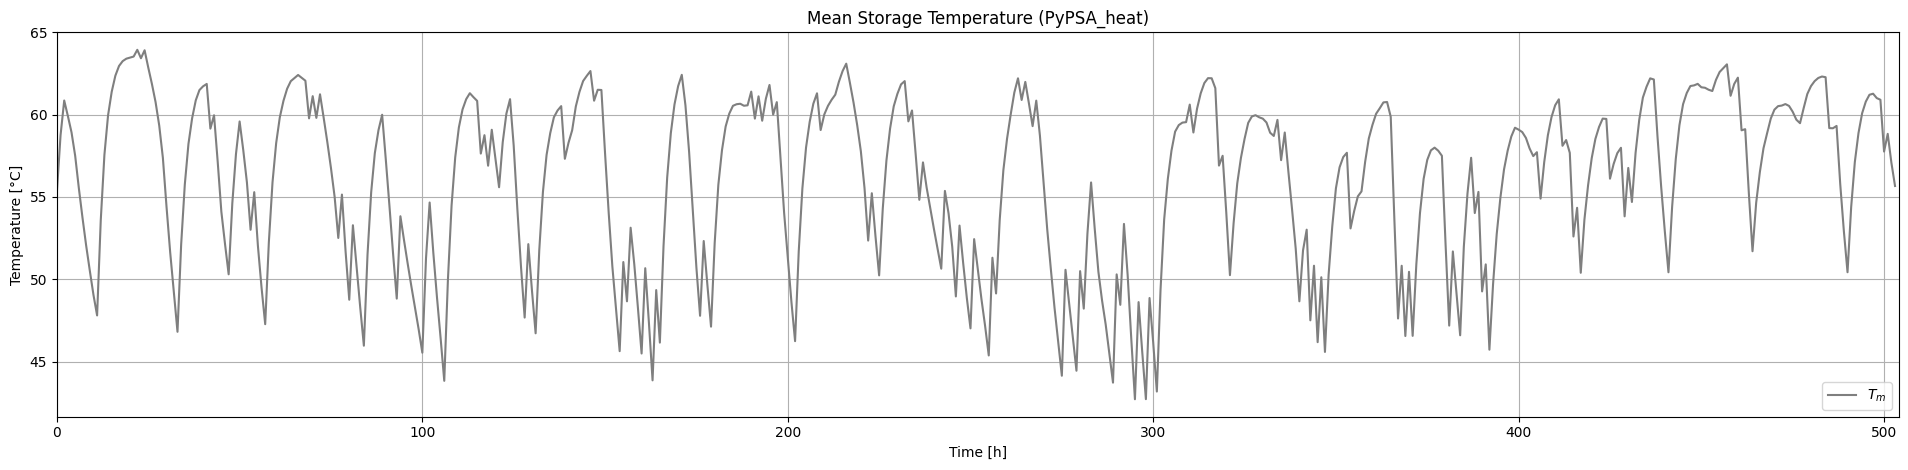

In [79]:
#Zuordnung der Ergebnisse aus dem Modell
#WP-Daten 
p_elec = n.heat_pumps_t.p_elec
p_heat = n.heat_pumps_t.p_heat
m_flow = n.heat_pumps_t.m_flow
COP = n.heat_pumps_t.COP
status = n.heat_pumps_t.status

#Mitteltemperatur der Schichten 3 Wochen
hs_m = heatstore_daten['hs'].mean(axis=1)
hs_m.plot(label='$T_m$', figsize=(19.2, 4.8), color='tab:grey')

plt.title('Mean Storage Temperature (PyPSA_heat)')
plt.xlabel('Time [h]')
plt.ylabel('Temperature [°C]')
plt.xlim(0, 504)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))
plt.grid()
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/py_speicherschichten_m - 3 Wochen.png')
plt.show()

In [20]:
# Berechnung der Kosten für den Netzbezug durch die Wärmepumpe
cost_grid = p_elec * grid_cost
total_cost_grid = cost_grid.sum().sum()

print(f"Kosten Netzbezug durch WP: {total_cost_grid:.2f} €")

Kosten Netzbezug durch WP: 511.59 €


# TRNSYS Ergebnisse

In [21]:
TRNSYSinputs = [
    "Inputs/TRNSYS/Volumen/TRNSYSMassenstromHausseitig3weeks.csv",
    "Inputs/TRNSYS/Volumen/TRNSYSRaumwärmebedarf3weeks.csv",
    "Inputs/TRNSYS/Volumen/TRNSYSRücklauftemperatur3weeks.csv",
    "Inputs/TRNSYS/Volumen/TRNSYSspeichermitteltemperatur3weeks.csv",
    "Inputs/TRNSYS/Volumen/TRNSYSspeicherschichttemperaturen3weeks.csv",
    "Inputs/TRNSYS/Volumen/TRNSYSWärmepumpe3weeks.csv"
]

df_liste = []

for f in TRNSYSinputs:
    df = pd.read_csv(f, encoding='latin1', skipinitialspace=True, engine='python', quoting=3, sep=',')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    if 'TIME' in df.columns:
        df = df[pd.to_numeric(df['TIME'], errors='coerce').notnull()]
        df = df.apply(pd.to_numeric, errors='coerce')
        df['TIME'] = df['TIME'].round(2)
        df = df.set_index('TIME')
    
    df_liste.append(df)

TRNSYSdata3weeks = pd.concat(df_liste, axis=1).sort_index().reset_index()
TRNSYSdata3weeks = TRNSYSdata3weeks.rename(columns={'TIME':'Time', 'Massenstrom':'ts_m_heatspace', 'T_amb':'ts_T_amb', 'P_heatspace':'ts_P_heatspace', 'T_R':'ts_T_R', 'T_M':'ts_T_m', 'T_1':'ts_T_1', 'T_2':'ts_T_2','T_3':'ts_T_3', 'p_heat':'ts_P_heat', 'm_flow':'ts_m_flow'})
TRNSYSdata3weeks = TRNSYSdata3weeks.round(6)
TRNSYSdata3weeks

,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_T_1,ts_T_2,ts_T_3,ts_P_heat,ts_m_flow
0,0.0,146.376469,6.286,1.7,49.884832,55.109029,59.884832,54.914720,50.527535,11.613,700.0
1,1.0,146.376469,5.997,1.7,49.172915,54.619945,59.172915,54.334401,50.352519,0.000,0.0
2,2.0,154.986841,5.705,1.8,47.815450,53.654830,57.815450,53.277876,49.871164,0.000,0.0
3,3.0,146.376469,5.534,1.7,50.275374,56.104684,60.275374,55.827612,52.211067,9.152,700.0
4,4.0,154.986841,5.451,1.8,51.436150,57.320309,61.436150,57.067599,53.457178,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
499,499.0,499.402073,-4.842,5.8,53.501779,60.995291,63.501779,61.339858,58.144238,5.612,700.0
500,500.0,499.402073,-5.690,5.8,52.033366,59.131960,62.033366,59.405845,55.956670,0.000,0.0
501,501.0,482.181288,-6.235,5.6,51.839684,58.613361,61.839684,58.706708,55.293691,7.582,700.0
502,502.0,275.532173,-6.605,3.2,51.333927,58.062868,61.333927,58.092398,54.762278,0.000,0.0


c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

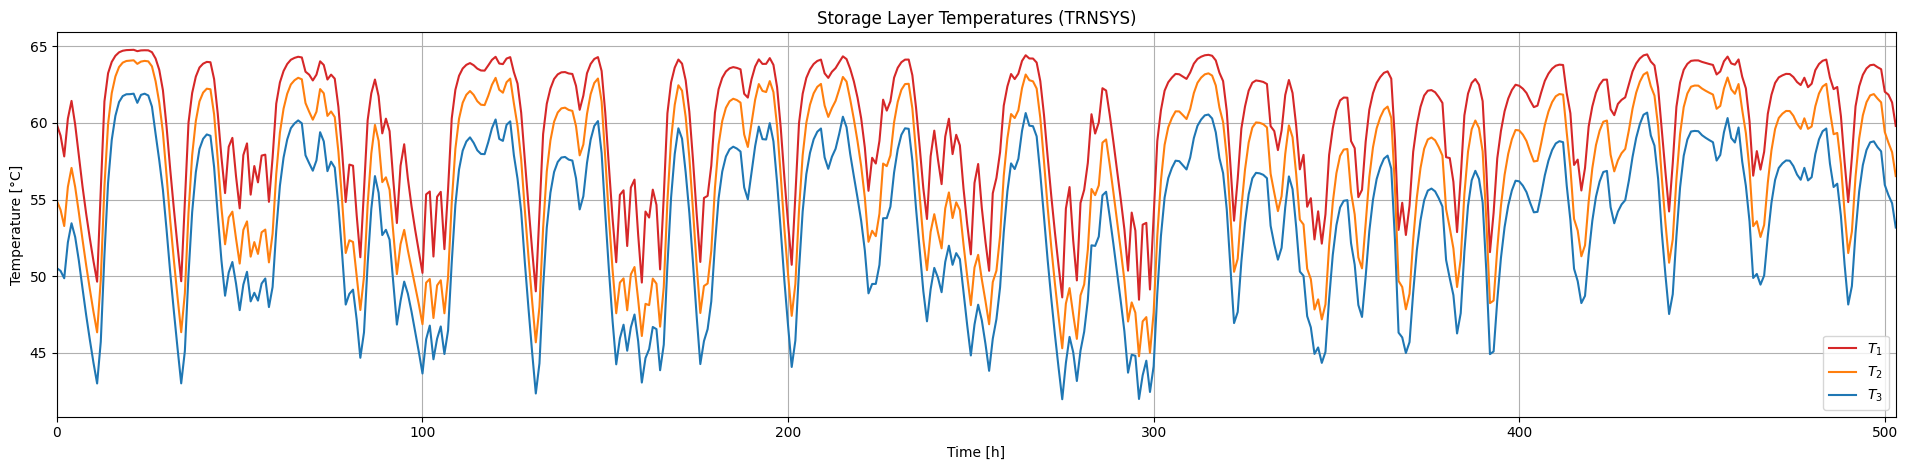

In [80]:
TRNSYS_T_s = TRNSYSdata3weeks[['ts_T_1', 'ts_T_2', 'ts_T_3']].copy()
TRNSYS_T_s.columns = ['T_1', 'T_2', 'T_3']
TRNSYS_T_s.plot(figsize=(19.2, 4.8), color=['tab:red', 'tab:orange', 'tab:blue'])

plt.title('Storage Layer Temperatures (TRNSYS)')
plt.xlabel('Time [h]')
plt.ylabel('Temperature [°C]')
plt.xlim(0, 503)
plt.legend(labels=['$T_1$', '$T_2$', '$T_3$'], loc='lower right', bbox_to_anchor=(1, 0))
plt.grid()
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/ts_speicherschichten - 3 Wochen.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

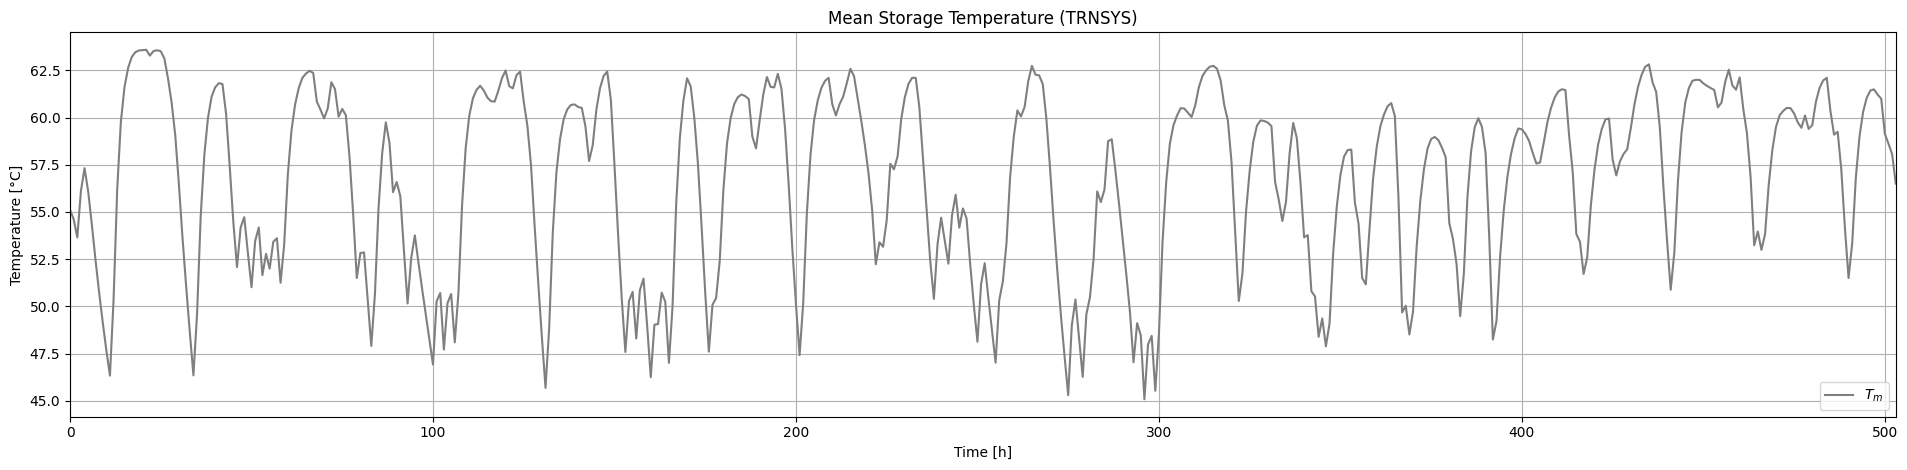

In [81]:
TRNSYS_T_m = TRNSYSdata3weeks['ts_T_m'].copy()
TRNSYS_T_m.plot(figsize=(19.2, 4.8), label='$T_m$', color='tab:grey')

plt.title('Mean Storage Temperature (TRNSYS)')
plt.xlabel('Time [h]')
plt.ylabel('Temperature [°C]')
plt.xlim(0, 503)
plt.legend(labels=['$T_m$'], loc='lower right', bbox_to_anchor=(1, 0))
plt.grid()
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/ts_speicherschichten_m - 3 Wochen.png')
plt.show()

# CSV-Ausgabe

In [24]:
# Kombinierten DataFrame erstellen
output_pypsa = pd.DataFrame({
    'py_P_elec': p_elec.values.flatten(),
    'py_P_heat': p_heat.values.flatten(),
    'py_m_flow': m_flow.values.flatten(),
    'py_COP': COP.values.flatten(),
    'py_status': status.values.flatten(),
    'py_T_1': heatstore_daten['hs'][1].values.flatten(),
    'py_T_2': heatstore_daten['hs'][2].values.flatten(),
    'py_T_3': heatstore_daten['hs'][3].values.flatten(),
    'py_T_m': hs_m.values.flatten(),
})

output_pypsa.to_csv(
    "Outputs/konstanterVolumenspeicher - 3 Wochen/output_pypsa_3_weeks.csv",
    sep=",",
    index_label="index",
    float_format="%.3f"
)

# Konsistenzcheck vor dem Zusammenführen
assert len(output_pypsa) == len(TRNSYSdata3weeks), "Unterschiedliche Zeilenanzahl!"

output_combined = pd.merge(
    output_pypsa, TRNSYSdata3weeks,
    left_index=True, right_index=True
)
output_combined

,py_P_elec,py_P_heat,py_m_flow,py_COP,py_status,py_T_1,py_T_2,py_T_3,py_T_m,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_T_1,ts_T_2,ts_T_3,ts_P_heat,ts_m_flow
0,6.184636,11.627116,700.0,1.88,1.0,60.079622,55.181206,50.698016,55.319615,0.0,146.376469,6.286,1.7,49.884832,55.109029,59.884832,54.914720,50.527535,11.613,700.0
1,4.370424,8.128988,700.0,1.86,1.0,62.430461,58.832221,55.000903,58.754528,1.0,146.376469,5.997,1.7,49.172915,54.619945,59.172915,54.334401,50.352519,0.000,0.0
2,3.115323,5.763348,700.0,1.85,1.0,63.565437,61.107458,57.910769,60.861221,2.0,154.986841,5.705,1.8,47.815450,53.654830,57.815450,53.277876,49.871164,0.000,0.0
3,0.000000,0.000000,-0.0,1.84,-0.0,62.806348,60.161807,56.794224,59.920793,3.0,146.376469,5.534,1.7,50.275374,56.104684,60.275374,55.827612,52.211067,9.152,700.0
4,0.000000,0.000000,-0.0,1.84,-0.0,61.954973,59.138401,55.688181,58.927185,4.0,154.986841,5.451,1.8,51.436150,57.320309,61.436150,57.067599,53.457178,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,3.957374,5.659045,700.0,1.43,1.0,63.445821,61.236451,58.039067,60.907113,499.0,499.402073,-4.842,5.8,53.501779,60.995291,63.501779,61.339858,58.144238,5.612,700.0
500,0.000000,0.000000,-0.0,1.40,-0.0,60.785468,57.978579,54.520925,57.761657,500.0,499.402073,-5.690,5.8,52.033366,59.131960,62.033366,59.405845,55.956670,0.000,0.0
501,5.498200,7.642499,700.0,1.39,1.0,61.974475,58.934022,55.599312,58.835936,501.0,482.181288,-6.235,5.6,51.839684,58.613361,61.839684,58.706708,55.293691,7.582,700.0
502,0.000000,0.000000,-0.0,1.38,-0.0,60.315969,57.167833,53.786464,57.090089,502.0,275.532173,-6.605,3.2,51.333927,58.062868,61.333927,58.092398,54.762278,0.000,0.0


In [25]:
output_combined_ordered = output_combined[[
    'Time', 'ts_m_heatspace', 'ts_T_amb', 'ts_P_heatspace',
    'py_P_elec', 'py_COP', 'py_status',
    'py_P_heat', 'ts_P_heat',
    'py_m_flow', 'ts_m_flow',
    'py_T_1', 'ts_T_1',
    'py_T_2', 'ts_T_2',
    'py_T_3', 'ts_T_3',
    'py_T_m', 'ts_T_m',
    'ts_T_R'
]]

output_combined_ordered.to_csv(
    "Outputs/konstanterVolumenspeicher - 3 Wochen/output_combined_ordered - 3 Wochen.csv",
    sep=",",
    index_label="index",
    float_format="%.3f"
)
output_combined_ordered

,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,py_P_elec,py_COP,py_status,py_P_heat,ts_P_heat,py_m_flow,ts_m_flow,py_T_1,ts_T_1,py_T_2,ts_T_2,py_T_3,ts_T_3,py_T_m,ts_T_m,ts_T_R
0,0.0,146.376469,6.286,1.7,6.184636,1.88,1.0,11.627116,11.613,700.0,700.0,60.079622,59.884832,55.181206,54.914720,50.698016,50.527535,55.319615,55.109029,49.884832
1,1.0,146.376469,5.997,1.7,4.370424,1.86,1.0,8.128988,0.000,700.0,0.0,62.430461,59.172915,58.832221,54.334401,55.000903,50.352519,58.754528,54.619945,49.172915
2,2.0,154.986841,5.705,1.8,3.115323,1.85,1.0,5.763348,0.000,700.0,0.0,63.565437,57.815450,61.107458,53.277876,57.910769,49.871164,60.861221,53.654830,47.815450
3,3.0,146.376469,5.534,1.7,0.000000,1.84,-0.0,0.000000,9.152,-0.0,700.0,62.806348,60.275374,60.161807,55.827612,56.794224,52.211067,59.920793,56.104684,50.275374
4,4.0,154.986841,5.451,1.8,0.000000,1.84,-0.0,0.000000,0.000,-0.0,0.0,61.954973,61.436150,59.138401,57.067599,55.688181,53.457178,58.927185,57.320309,51.436150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,499.0,499.402073,-4.842,5.8,3.957374,1.43,1.0,5.659045,5.612,700.0,700.0,63.445821,63.501779,61.236451,61.339858,58.039067,58.144238,60.907113,60.995291,53.501779
500,500.0,499.402073,-5.690,5.8,0.000000,1.40,-0.0,0.000000,0.000,-0.0,0.0,60.785468,62.033366,57.978579,59.405845,54.520925,55.956670,57.761657,59.131960,52.033366
501,501.0,482.181288,-6.235,5.6,5.498200,1.39,1.0,7.642499,7.582,700.0,700.0,61.974475,61.839684,58.934022,58.706708,55.599312,55.293691,58.835936,58.613361,51.839684
502,502.0,275.532173,-6.605,3.2,0.000000,1.38,-0.0,0.000000,0.000,-0.0,0.0,60.315969,61.333927,57.167833,58.092398,53.786464,54.762278,57.090089,58.062868,51.333927


# Combined Plots

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

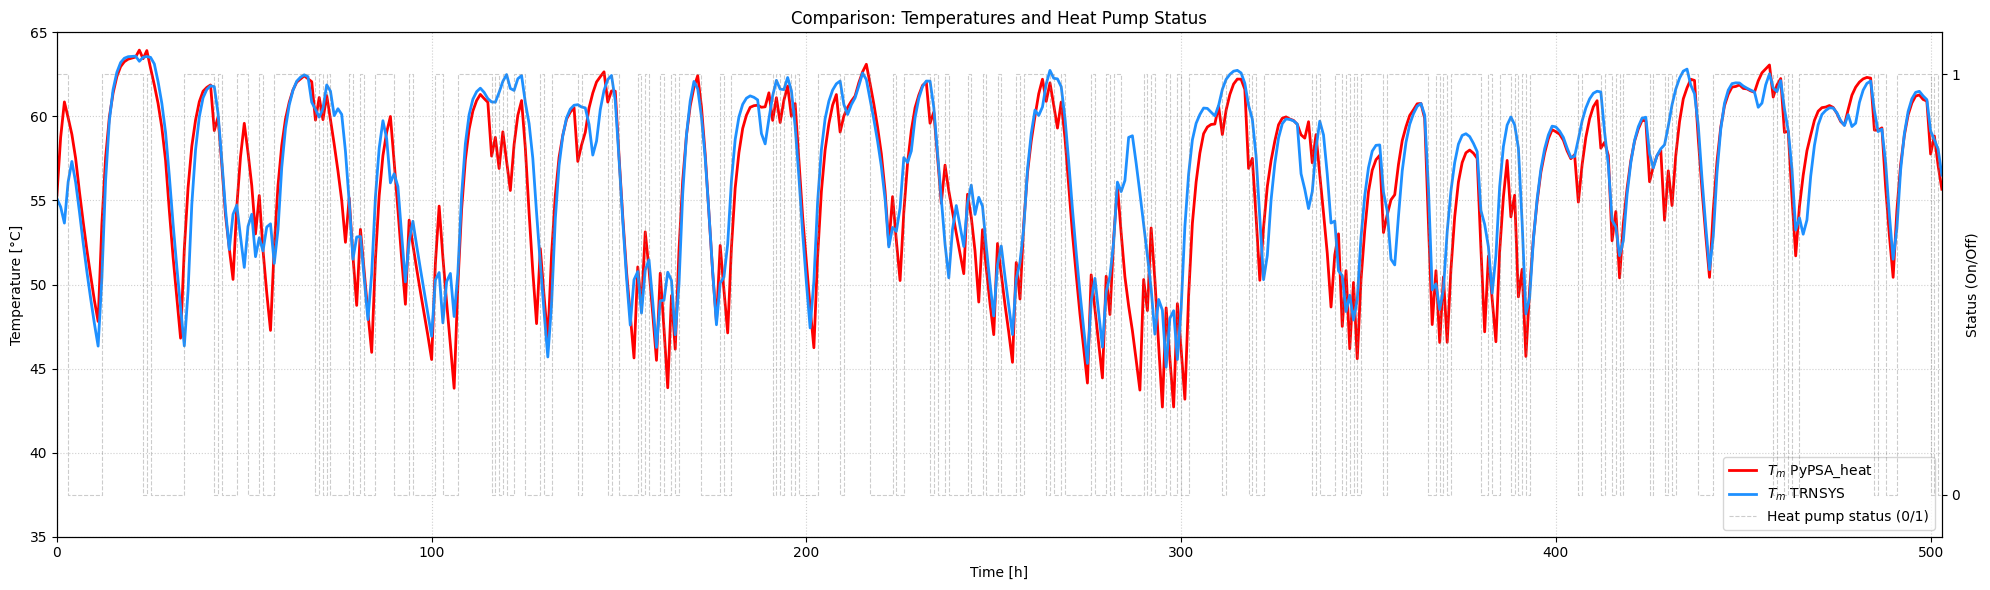

In [98]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(20, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='$T_m$ PyPSA_heat', linewidth=2, color='red')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_m'], label='$T_m$ TRNSYS', linewidth=2, color='dodgerblue')
ax1.set_title('Comparison: Temperatures and Heat Pump Status')
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Temperature [°C]')
ax1.set_xlim(0, 503)
ax1.set_ylim(35, 65)  # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Rechte y-Achse: WP Status (0 oder 1) ---
ax2 = ax1.twinx()
# drawstyle='steps-post' macht den An/Aus-Charakter deutlich
ax2.plot(output_pypsa.index, output_pypsa['py_status'],
         label='Heat pump status (0/1)', color='grey', linestyle='--', drawstyle='steps-post', alpha=0.4, linewidth=.8)
ax2.set_ylabel('Status (On/Off)')
ax2.set_ylim(-0.1, 1.1)  # Etwas Puffer nach oben/unten, damit man die Linie besser sieht
ax2.set_yticks([0, 1])  # Nur 0 und 1 anzeigen

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='lower right', bbox_to_anchor=(1, 0)
)

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/vergleich_T_m+status - 3 Wochen.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

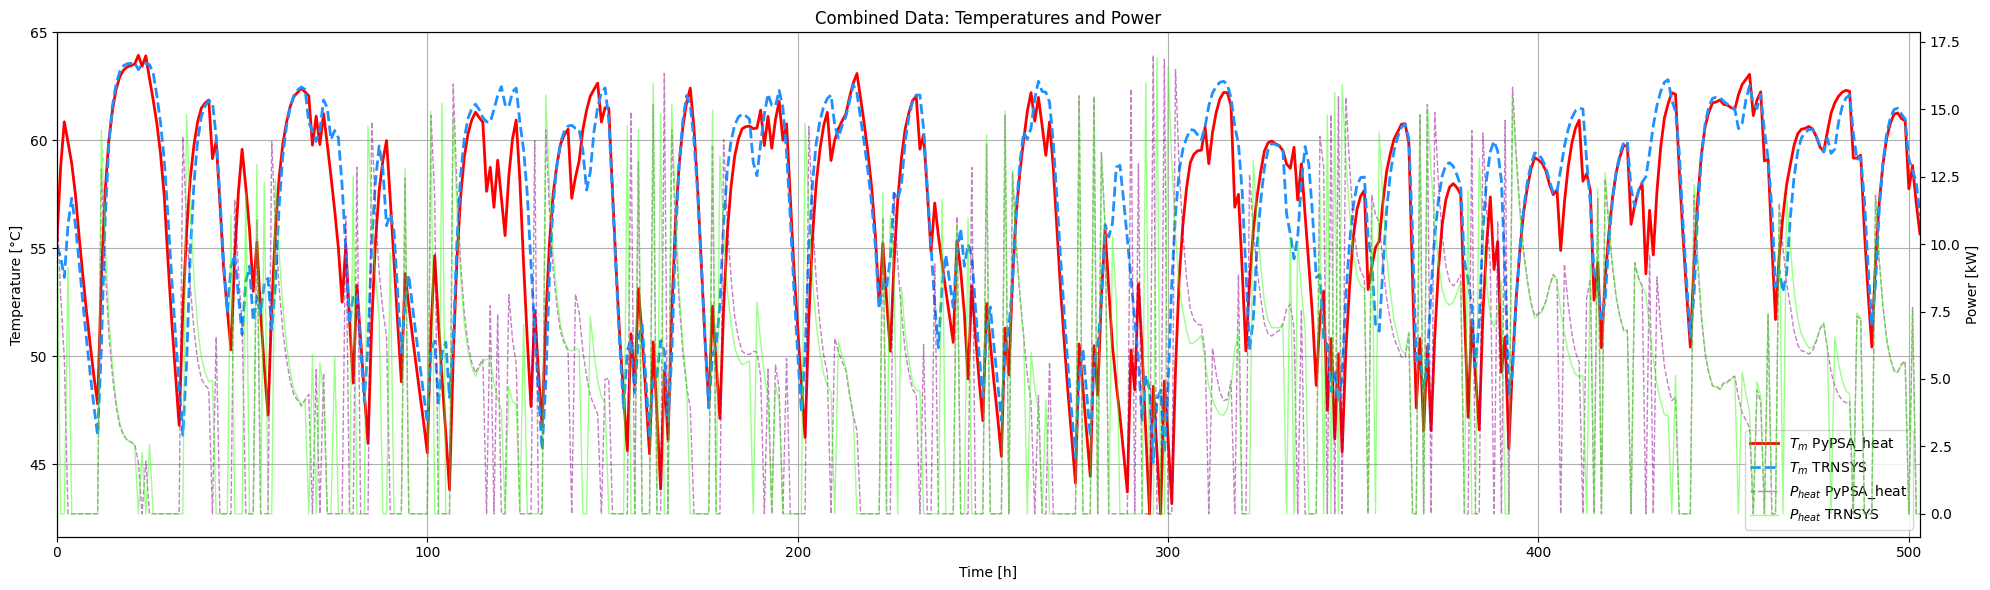

In [119]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(20, 6))

# Plotten der Temperaturen beider Datenquellen auf ax1
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='$T_m$ PyPSA_heat', linewidth=2, color='red')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_m'], label='$T_m$ TRNSYS', linewidth=2, linestyle='--', color='dodgerblue')
ax1.set_title('Combined Data: Temperatures and Power')
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Temperature [°C]')
ax1.set_xlim(0, 503)
ax1.grid(True)

# Rechte y-Achse: Leistungen (in kW)
ax2 = ax1.twinx()

# Plotten der Leistungen aus output_pypsa
ax2.plot(output_pypsa.index, output_pypsa['py_P_heat'], label='$P_{heat}$ PyPSA_heat', color='#8B008B', linestyle='--', linewidth=1, alpha=0.5)

# Optional: Falls TRNSYS Leistung auch geplottet werden soll
if 'ts_P_heat' in TRNSYSdata3weeks.columns:
    ax2.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_P_heat'], label='$P_{heat}$ TRNSYS', color='#39FF14', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_ylabel('Power [kW]')

# Legende für beide Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='lower right', bbox_to_anchor=(1, 0)
)

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/vergleich_T_m+p_heat - 3 Wochen.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

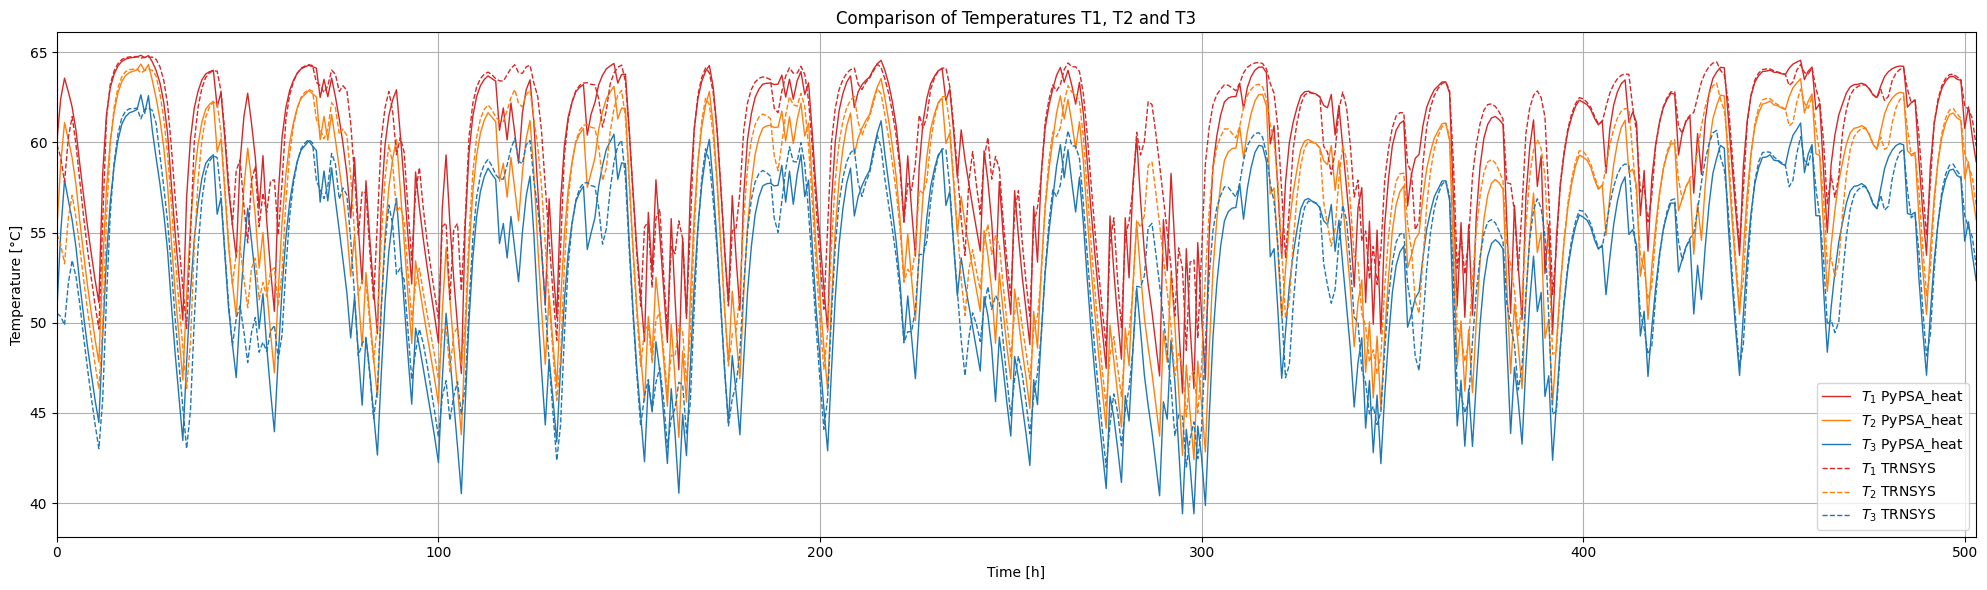

In [108]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(20, 6))

# Plotten der Temperaturen T1, T2 und T3
# Python Daten
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='$T_1$ PyPSA_heat', linewidth=1, color = 'tab:red')
ax1.plot(output_pypsa.index, output_pypsa['py_T_2'], label='$T_2$ PyPSA_heat', linewidth=1, color = 'tab:orange')
ax1.plot(output_pypsa.index, output_pypsa['py_T_3'], label='$T_3$ PyPSA_heat', linewidth=1, color = 'tab:blue')

# TRNSYS Daten (gestrichelt für bessere Unterscheidung)
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_1'], label='$T_1$ TRNSYS', linewidth=1, linestyle='--', color = 'tab:red')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_2'], label='$T_2$ TRNSYS', linewidth=1, linestyle='--', color = 'tab:orange')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_3'], label='$T_3$ TRNSYS', linewidth=1, linestyle='--', color = 'tab:blue')

ax1.set_title('Comparison of Temperatures T1, T2 and T3')
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Temperature [°C]')
ax1.set_xlim(0, 503)
ax1.grid(True)
ax1.legend(loc='lower right', bbox_to_anchor=(1, 0))  # Fügt die Legende hinzu, um die Linien zu unterscheiden

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Vergleich der Temperaturen T1, T2 und T3 - 3 Wochen.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

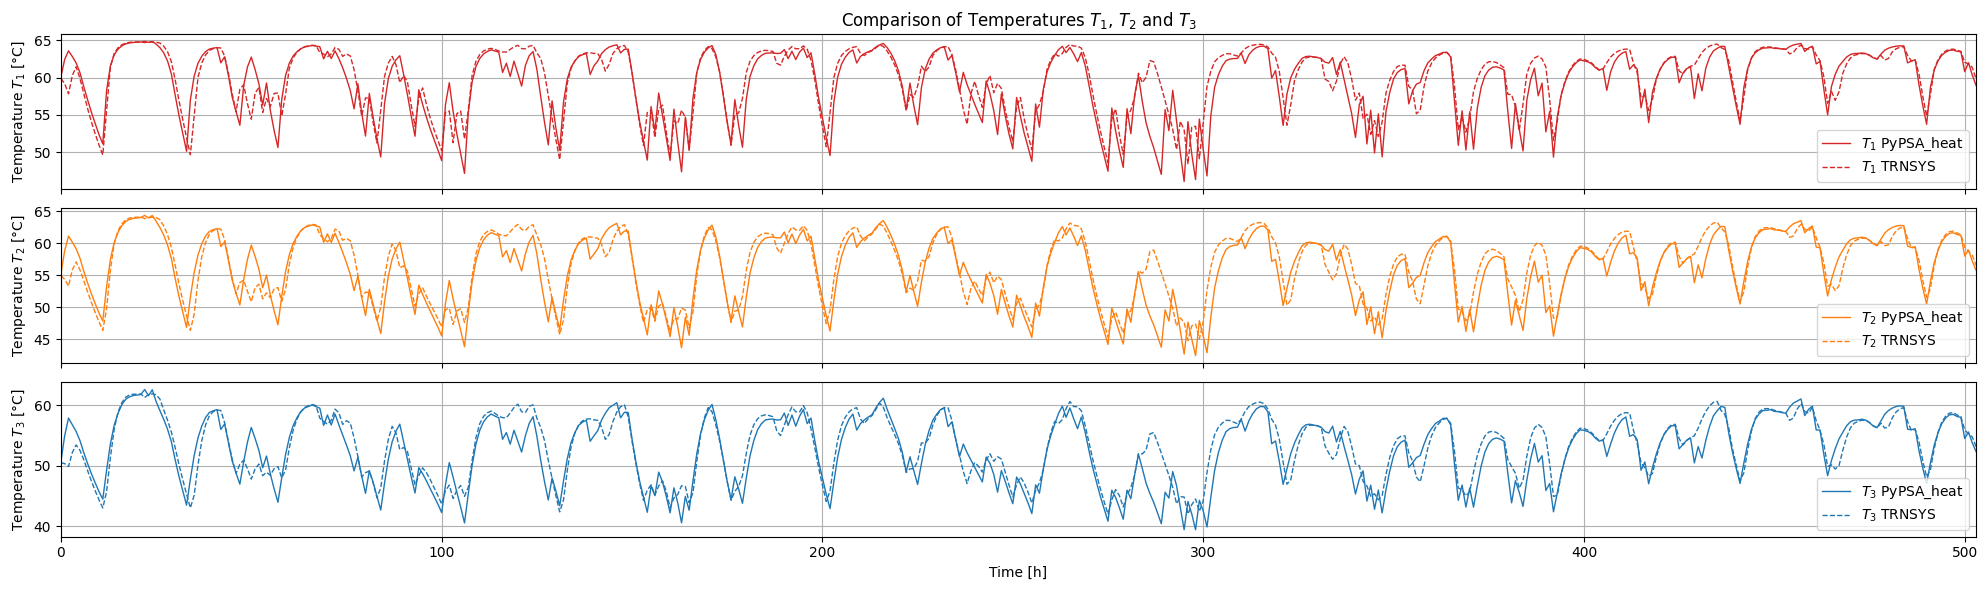

In [115]:
# sharex=True sorgt dafür, dass die X-Achse für alle Plots gleich ist
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 6), sharex=True)

# --- Plot für T1 ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='$T_1$ PyPSA_heat', linewidth=1, color = 'tab:red')
ax1.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_1'], label='$T_1$ TRNSYS', linewidth=1, linestyle='--', color = 'tab:red')
ax1.set_ylabel('Temperature $T_1$ [°C]')
ax1.set_title('Comparison of Temperatures $T_1$, $T_2$ and $T_3$')
ax1.grid(True)
ax1.legend(loc='lower right', bbox_to_anchor=(1, 0))

# --- Plot für T2 ---
ax2.plot(output_pypsa.index, output_pypsa['py_T_2'], label='$T_2$ PyPSA_heat', linewidth=1, color='tab:orange')
ax2.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_2'], label='$T_2$ TRNSYS', linewidth=1, linestyle='--', color='tab:orange')
ax2.set_ylabel('Temperature $T_2$ [°C]')
ax2.grid(True)
ax2.legend(loc='lower right', bbox_to_anchor=(1, 0))

# --- Plot für T3 ---
ax3.plot(output_pypsa.index, output_pypsa['py_T_3'], label='$T_3$ PyPSA_heat', linewidth=1, color='tab:blue')
ax3.plot(TRNSYSdata3weeks.index, TRNSYSdata3weeks['ts_T_3'], label='$T_3$ TRNSYS', linewidth=1, linestyle='--', color='tab:blue')
ax3.set_ylabel('Temperature $T_3$ [°C]')
ax3.set_xlabel('Time [h]')
ax3.set_xlim(0, 503)
ax3.grid(True)
ax3.legend(loc='lower right', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Vergleich der Temperaturen T1, T2 und T3 - 3 Wochen - einzelne Grafiken.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

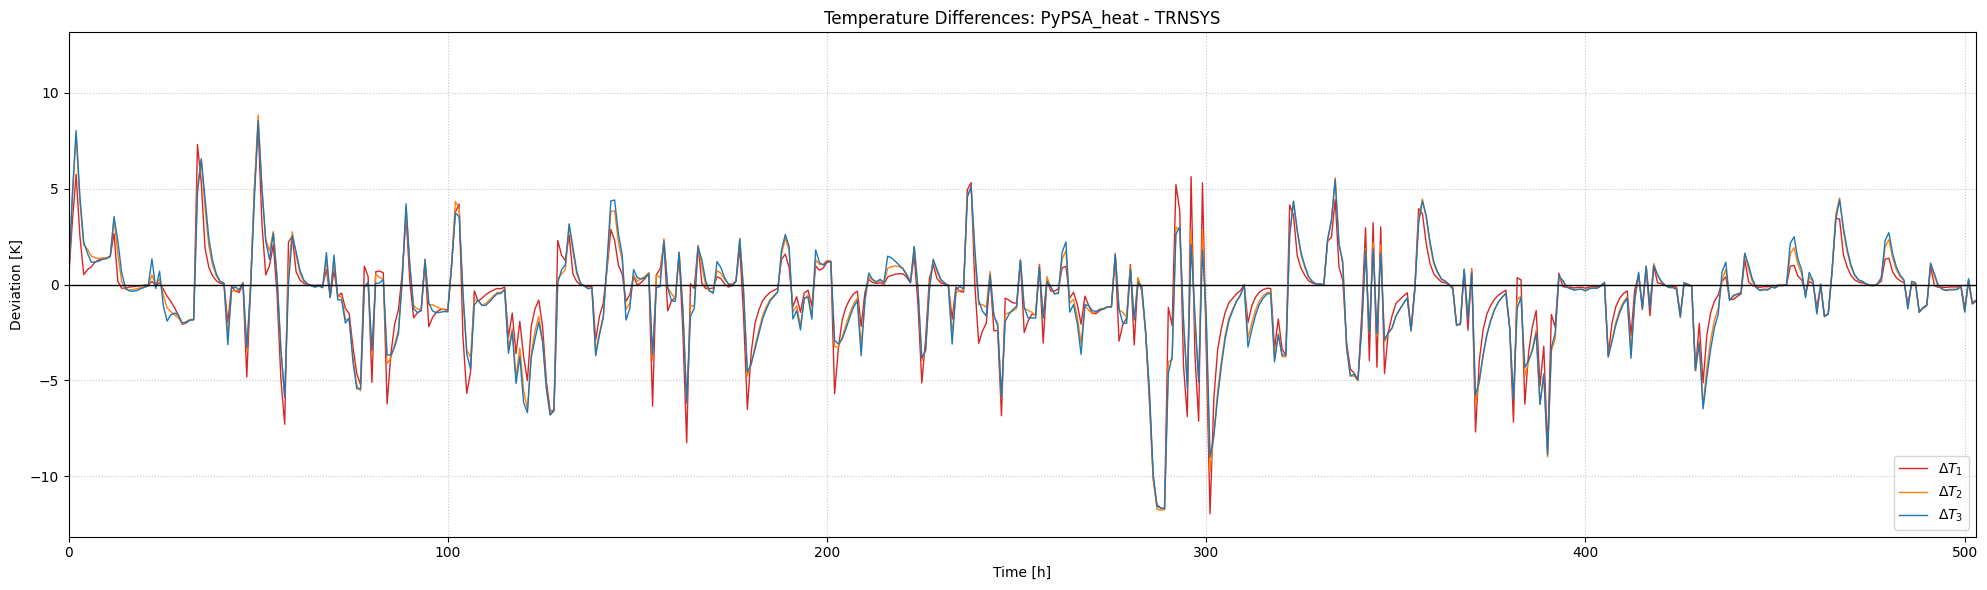

In [118]:
# Berechnung der Differenzen (Python - TRNSYS)
delta_T_1 = output_pypsa['py_T_1'] - TRNSYSdata3weeks['ts_T_1']
delta_T_2 = output_pypsa['py_T_2'] - TRNSYSdata3weeks['ts_T_2']
delta_T_3 = output_pypsa['py_T_3'] - TRNSYSdata3weeks['ts_T_3']

# Erstelle Figur
fig, ax = plt.subplots(figsize=(20, 6))

# Plotten der Differenzen
ax.plot(output_pypsa.index, delta_T_1, label='$Δ T_1$', linewidth=1, color='tab:red')
ax.plot(output_pypsa.index, delta_T_2, label='$Δ T_2$', linewidth=1, color='tab:orange')
ax.plot(output_pypsa.index, delta_T_3, label='$Δ T_3$', linewidth=1, color='tab:blue')

# Null-Linie als Referenz (Zentrum)
ax.axhline(0, color='black', linewidth=1, linestyle='-')

# Achseneinstellungen
ax.set_title('Temperature Differences: PyPSA_heat - TRNSYS')
ax.set_xlabel('Time [h]')
ax.set_ylabel('Deviation [K]')
ax.set_xlim(0, 503)

# Symmetrische Y-Achse für Null in der Mitte
limit = max(abs(delta_T_1).max(), abs(delta_T_2).max(), abs(delta_T_3).max()) * 1.1
ax.set_ylim(-limit, limit)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='lower right', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Temperaturdifferenzen - 3 Wochen.png')
plt.show()

c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\masterprojekt\.venv\Lib\site-packages\pyparsing\util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
c:\masterprojekt\.venv\Lib\site-packages\matplotlib\_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\masterprojekt\.venv\Lib\site-packages\matplotlib

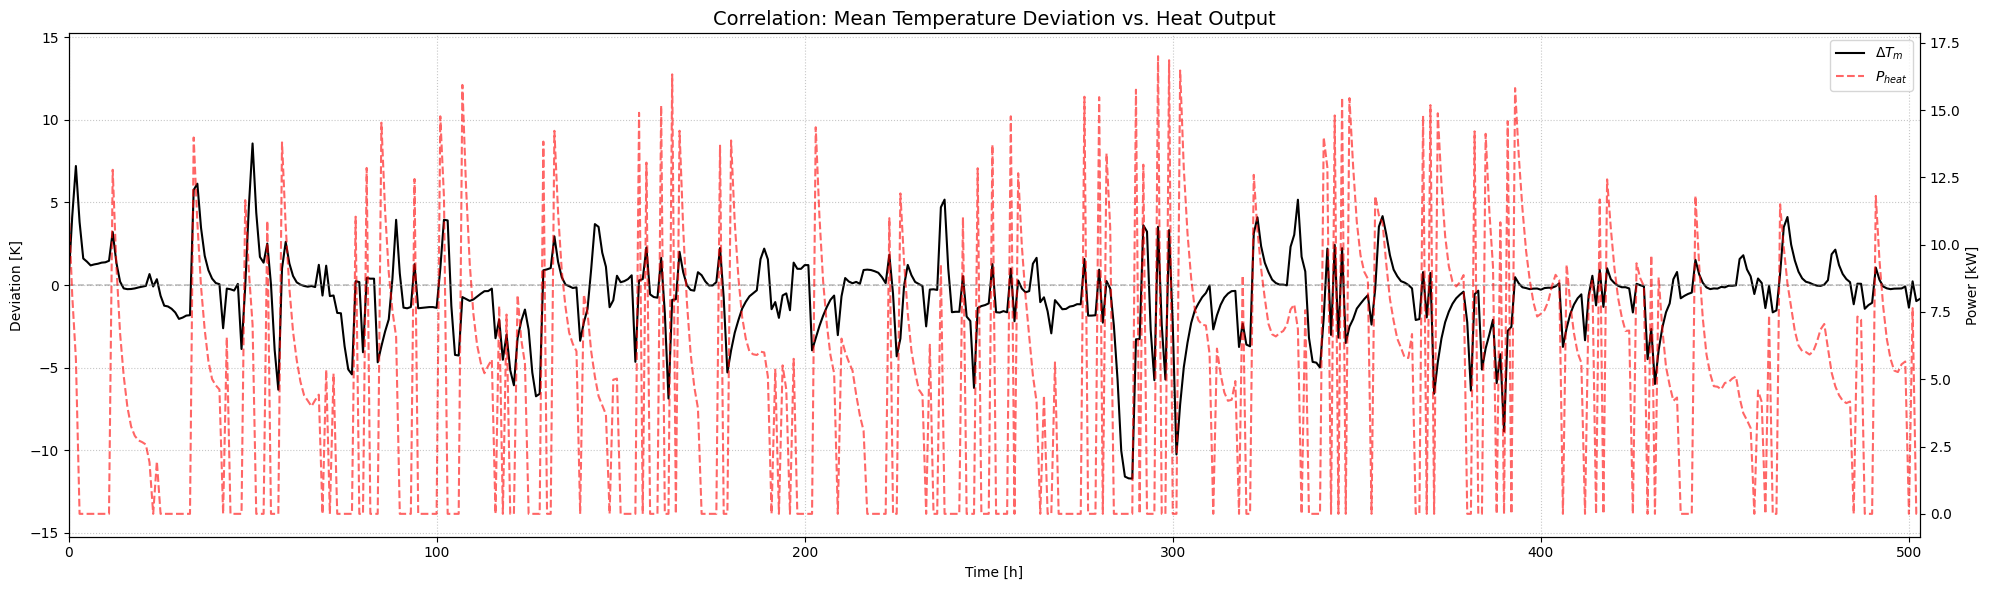

In [117]:
delta_T_m = output_pypsa['py_T_m'] - TRNSYSdata3weeks['ts_T_m']

fig, ax1 = plt.subplots(figsize=(20, 6))

ax1.plot(output_pypsa.index, delta_T_m, label='$Δ T_m$', color='black')
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Deviation [K]')
ax1.tick_params(axis='y')
ax1.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.5)

limit = abs(delta_T_m).max() * 1.3 if abs(delta_T_m).max() > 0 else 1
ax1.set_ylim(-limit, limit)

ax2 = ax1.twinx()
ax2.plot(output_combined.index, output_combined.py_P_heat, label='$P_{heat}$', color='red',linestyle='--', alpha=0.6)
ax2.set_ylabel('Power [kW]')
ax2.tick_params(axis='y')

plt.title('Correlation: Mean Temperature Deviation vs. Heat Output', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', bbox_to_anchor=(1, 1))

ax1.set_xlim(0, 503)

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Korrelation - Mittlere Temperaturdifferenz vs. Wärmeleistung - 3 Wochen.png')
plt.show()

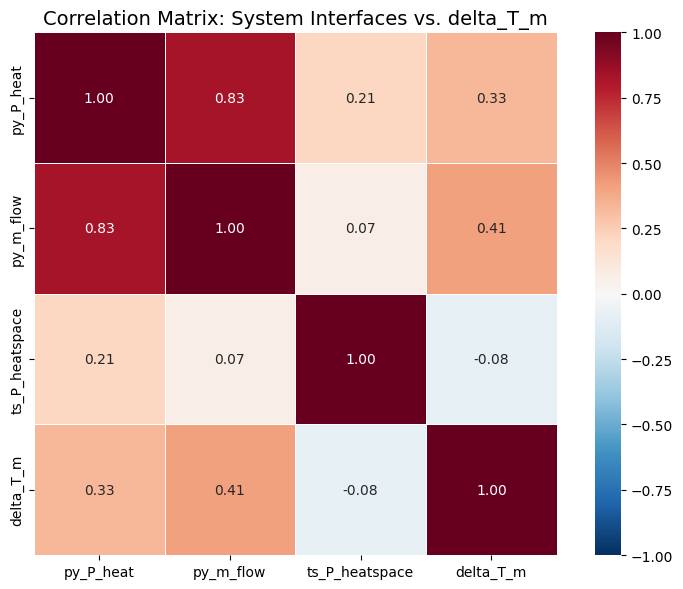

In [32]:
correlation_cols = [
    'py_P_heat', 
    'py_m_flow', 
    'ts_P_heatspace'
]
matrix_df = output_combined[correlation_cols].copy()
matrix_df['delta_T_m'] = delta_T_m

full_corr_matrix = matrix_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(full_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt='.2f',
            square=True,
            linewidths=.5)
plt.title('Correlation Matrix: System Interfaces vs. delta_T_m', fontsize=14)
plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Korrelationsmatrix Systemschnittstellen vs. delta_T_m - 3 Wochen.png')
plt.show()

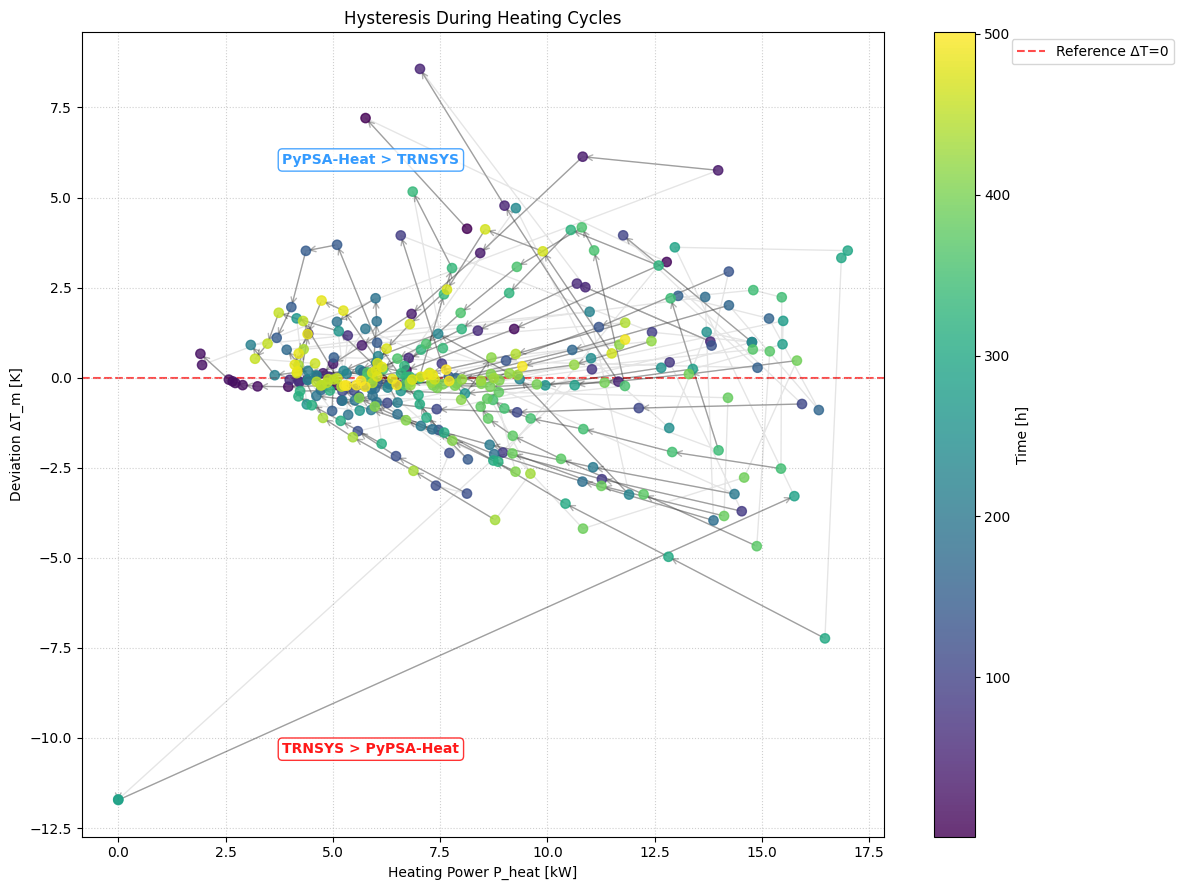

In [33]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()
plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Reference ΔT=0', zorder=1)

plt.text(0.25, 0.85, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.9, ha='left', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='dodgerblue', alpha=0.8, boxstyle='round,pad=0.3'),
         zorder=5)
plt.text(0.25, 0.1, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.9, ha='left', va='bottom',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.8, boxstyle='round,pad=0.3'),
         zorder=5)

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysteresis During Heating Cycles')
plt.xlabel('Heating Power P_heat [kW]')
plt.ylabel('Deviation ΔT_m [K]')
plt.colorbar(scatter, label='Time [h]')
plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Hysterese während Heizvorgängen - 3 Wochen.png')
plt.show()

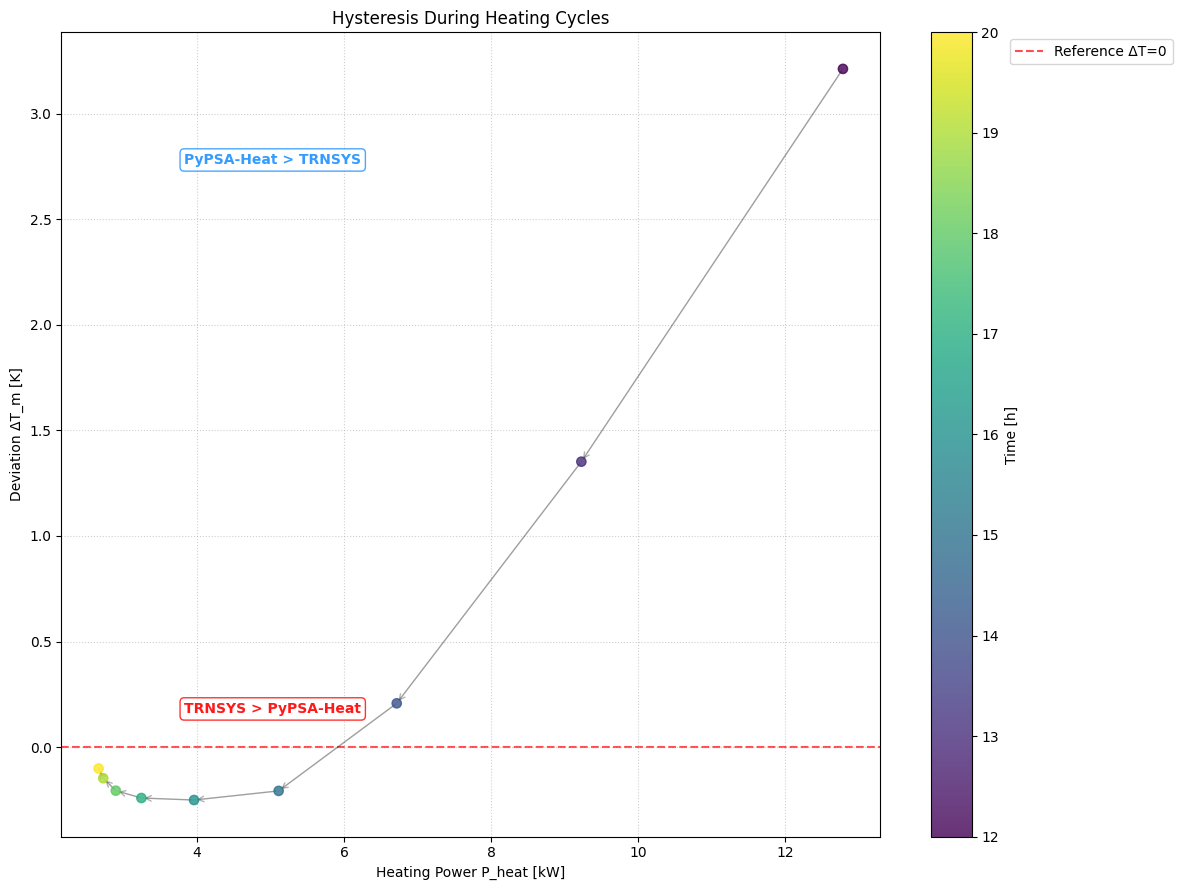

In [34]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()
plot_data = plot_data[(plot_data['index'] >= 5) & (plot_data['index'] <= 20)]
plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Reference ΔT=0', zorder=1)

plt.text(0.15, 0.85, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.9, ha='left', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='dodgerblue', alpha=0.8, boxstyle='round,pad=0.3'),
         zorder=5)
plt.text(0.15, 0.15, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.9, ha='left', va='bottom',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.8, boxstyle='round,pad=0.3'),
         zorder=5)

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysteresis During Heating Cycles')
plt.xlabel('Heating Power P_heat [kW]')
plt.ylabel('Deviation ΔT_m [K]')
plt.colorbar(scatter, label='Time [h]')
plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('Outputs/konstanterVolumenspeicher - 3 Wochen/Hysterese während Heizvorgängen - 3 Wochen.png')
plt.show()

In [35]:
delta_T_m.sum()

-329.3790225234042

### Bestimmung der Abweichungen zwischen pypsa_heat und TRYNSIS

#### Mean Absolute Error
The mean absolute error (MAE) is defined as a measure of the average absolute deviation of a model from a reference value. Since deviations are taken as absolute values, the MAE does not indicate whether the model tends to underestimate or overestimate, but only how large the typical deviation is.

Differenz aus jedem Messpunkt (Vorzeichen unwichtig) und dann den Durchschnittswert

In [36]:
#Berechnung der mittleren absoluten Abweichung (MAE) für jede Schicht

schichten = ["T_1", "T_2", "T_3", "T_m"]
# MAE
abweichung_df = {}

for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abweichung_df[s] = np.mean(np.abs(diff))

abweichung_df = pd.DataFrame.from_dict(abweichung_df, orient="index", columns=["MAE [K]"])
abweichung_df

,MAE [K]
T_1,1.596248
T_2,1.756912
T_3,1.812815
T_m,1.718082


#### RMSE – Root Mean Square Error
Wie MAE, aber durch das Quadrieren werden große Einzelabweichungen überproportional stark gewichtet. RMSE ≥ MAE ist immer der Fall; je größer der Abstand zwischen beiden, desto mehr "Ausreißer" oder ungleichmäßig verteilte Fehler stecken in den Daten.

Differenz aus jedem Messpunkt (Vorzeichen unwichtig), dann Quadriert (größere Abweichung werden sträker bestraft als kleinere) und dann den Durchschnittswert gebildet und dann die Wurzel gezogen

In [37]:
#Berechnung der mittleren absoluten Abweichung (MAE) für jede Schicht
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abweichung_df.loc[s, "RMSE [K]"] = np.sqrt((diff**2).mean())
    
abweichung_df

,MAE [K],RMSE [K]
T_1,1.596248,2.542791
T_2,1.756912,2.578265
T_3,1.812815,2.607770
T_m,1.718082,2.543387


####  CV(RMSE) – Coefficient of Variation of RMSE
RMSE normiert auf den Mittelwert – das eigentliche "Haupt-Gütekriterium", weil es Streuungsfehler *und* Normierung in einer Zahl vereint. Werte um 2 % liegen weit unter der ASHRAE-Schwelle von 30 %, sehr gut.

Der RMSE wird durch den Mittelwert geteilt, ergibt einen relativer Wert. Relative Werte sind hier aussagekräftiger als absolute Werte.

In [38]:
#Berechnung des CV(RMSE/Mean) für jede Schicht
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"
    ts_mean = np.mean(output_combined[ts_col])

    abweichung_df.loc[s, "CV(RMSE)[%]"] = abweichung_df.loc[s, "RMSE [K]"] / ts_mean * 100
    
abweichung_df

,MAE [K],RMSE [K],CV(RMSE)[%]
T_1,1.596248,2.542791,4.240730
T_2,1.756912,2.578265,4.552346
T_3,1.812815,2.607770,4.885289
T_m,1.718082,2.543387,4.488932


##### MBE - Mean Bias Error
Mean bias error (MBE) is defined as a measure of the tendency of a model to either underestimate or overestimate a value. A negative MBE indicates underestimation, while a positive MBE indicates overestimation.

Durschnittliche Abweichung aller Messwerte. Sagt aus ob unser System über- oder Unterschätz. In unserem Fall sind pypsa_heat Ergebnisse tendenziell geringer als die von TRYNSIS

In [39]:
# MBE
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abweichung_df.loc[s, "MBE [K]"] = np.mean(diff)
    
abweichung_df


,MAE [K],RMSE [K],CV(RMSE)[%],MBE [K]
T_1,1.596248,2.542791,4.240730,-0.665122
T_2,1.756912,2.578265,4.552346,-0.637253
T_3,1.812815,2.607770,4.885289,-0.658215
T_m,1.718082,2.543387,4.488932,-0.653530


#### NMBE - Normalized Mean Bias Error

The normalized mean bias error (NMBE) is defined as the mean bias error (MBE) normalized by the mean of the reference values, expressed as a percentage.

MBE / Mittelwert -> erhalten den Wert um wie viel Prozent pypsa_heat unter den TRYNSIS Ergebnissen liegt.

In [40]:
# NMBE
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    ts_mean = np.mean(output_combined[ts_col])
    abweichung_df.loc[s, "NMBE [%]"] = np.mean(diff) / ts_mean * 100
abweichung_df

,MAE [K],RMSE [K],CV(RMSE)[%],MBE [K],NMBE [%]
T_1,1.596248,2.542791,4.240730,-0.665122,-1.109254
T_2,1.756912,2.578265,4.552346,-0.637253,-1.125174
T_3,1.812815,2.607770,4.885289,-0.658215,-1.233072
T_m,1.718082,2.543387,4.488932,-0.653530,-1.153443


#### R² 
Es beantwortet wie ähnlich in der Dynamik die beiden Modelle sind. 1 = Perfekte übereinstimmung der Daten. 





In [41]:
# R²
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff_py_p_mean = output_combined[py_col] - np.mean(output_combined[py_col])
    diff_ts_p_mean = output_combined[ts_col] - np.mean(output_combined[ts_col])
    r_squared = (np.sum(diff_py_p_mean * diff_ts_p_mean) ** 2) / (np.sum(diff_py_p_mean ** 2) * np.sum(diff_ts_p_mean ** 2))
    ts_mean = np.mean(output_combined[ts_col])
    abweichung_df.loc[s, "R²"] = r_squared

abweichung_df

,MAE [K],RMSE [K],CV(RMSE)[%],MBE [K],NMBE [%],R²
T_1,1.596248,2.542791,4.240730,-0.665122,-1.109254,0.709386
T_2,1.756912,2.578265,4.552346,-0.637253,-1.125174,0.781057
T_3,1.812815,2.607770,4.885289,-0.658215,-1.233072,0.784211
T_m,1.718082,2.543387,4.488932,-0.653530,-1.153443,0.765902


#### MaxAbsDev + Zeitpunkt

In [42]:
# T_MaxAbsDev
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abs_diff = diff.abs()

    abweichung_df.loc[s, "MaxAbsDev [K]"] = abs_diff.max()
    abweichung_df.loc[s, "T_MaxAbsDev [h]"] = abs_diff.idxmax()

abweichung_df

,MAE [K],RMSE [K],CV(RMSE)[%],MBE [K],NMBE [%],R²,MaxAbsDev [K],T_MaxAbsDev [h]
T_1,1.596248,2.542791,4.240730,-0.665122,-1.109254,0.709386,11.969561,301.0
T_2,1.756912,2.578265,4.552346,-0.637253,-1.125174,0.781057,11.775482,288.0
T_3,1.812815,2.607770,4.885289,-0.658215,-1.233072,0.784211,11.698052,289.0
T_m,1.718082,2.543387,4.488932,-0.653530,-1.153443,0.765902,11.722312,289.0


In [43]:
abweichung_df.to_excel("Outputs/konstanterVolumenspeicher - 3 Wochen/Fehleranalyse_pypsa_trynsis.xlsx", index=True,)